# Задача №4.

Подготовка пайплайна решения задачи предсказания ВР

На основе прошлых заданий будем использовать лучшие решения и наработки для построения пайплайна предсказания временного ряда

Импорт библиотек

In [19]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os
from pyod.models.ts_spectral_residual import SpectralResidual

from mlforecast.lag_transforms import RollingMean, ExpandingMean
from statsforecast import StatsForecast


from statsforecast.models import (
    ARIMA,
    SeasonalNaive
)

# Стандартные библиотеки
import pandas as pd
import matplotlib.pyplot as plt

# Основные метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Для RMSE (корень из MSE) можно использовать:
from sklearn.metrics import mean_squared_error
import numpy as np


# mlforecast
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor



## 4.1 Загрузка данных

In [11]:
def load_data():
    """Загрузка и подготовка данных"""

    # Переход в корень проекта (если мы в папке notebooks)
    if os.getcwd().endswith('notebooks'):
        os.chdir('..')

    # Загружаем данные
    df = pd.read_csv('data/ETTh1.csv')

    # Переименовываем колонки
    df = df.rename(columns={
        'date': 'ds',    # колонка с датой → 'ds'
        'OT': 'y'        # целевая переменная → 'y'
    })

    # Преобразуем дату в datetime
    df['ds'] = pd.to_datetime(df['ds'])

    # Переход на дневные данные (для ускорения)
    df_daily = df[['ds', 'y']].copy()
    df_daily = df_daily.resample('D', on='ds').mean().reset_index()
    df_daily.columns = ['ds', 'y']

    # Добавляем колонку unique_id
    df_daily['unique_id'] = 'ETTh1'

    print(f" Данные загружены: {len(df_daily)} записей")
    print(f"   Период: {df_daily['ds'].min().date()} → {df_daily['ds'].max().date()}")

    return df_daily

# Запуск
df = load_data()
print(df.head())

 Данные загружены: 726 записей
   Период: 2016-07-01 → 2018-06-26
          ds          y unique_id
0 2016-07-01  21.071833     ETTh1
1 2016-07-02  22.039208     ETTh1
2 2016-07-03  26.626375     ETTh1
3 2016-07-04  27.162666     ETTh1
4 2016-07-05  30.102583     ETTh1


## 4.2 EDA (кратко)

Описание: 
--------------------------------------------------
Форма данных: (726, 3)
Индекс: None (тип: int64)
Диапазон дат: 0 — 725
--------------------------------------------------

Типы данных:
datetime64[ns]    1
float64           1
object            1
Name: count, dtype: int64
--------------------------------------------------

Пропуски:
Нет пропущенных значений.
--------------------------------------------------

Базовая статистика (числовые колонки):
ВИЗУАЛЬНЫЙ АНАЛИЗ ТЕМПЕРАТУРЫ МАСЛА (OT)


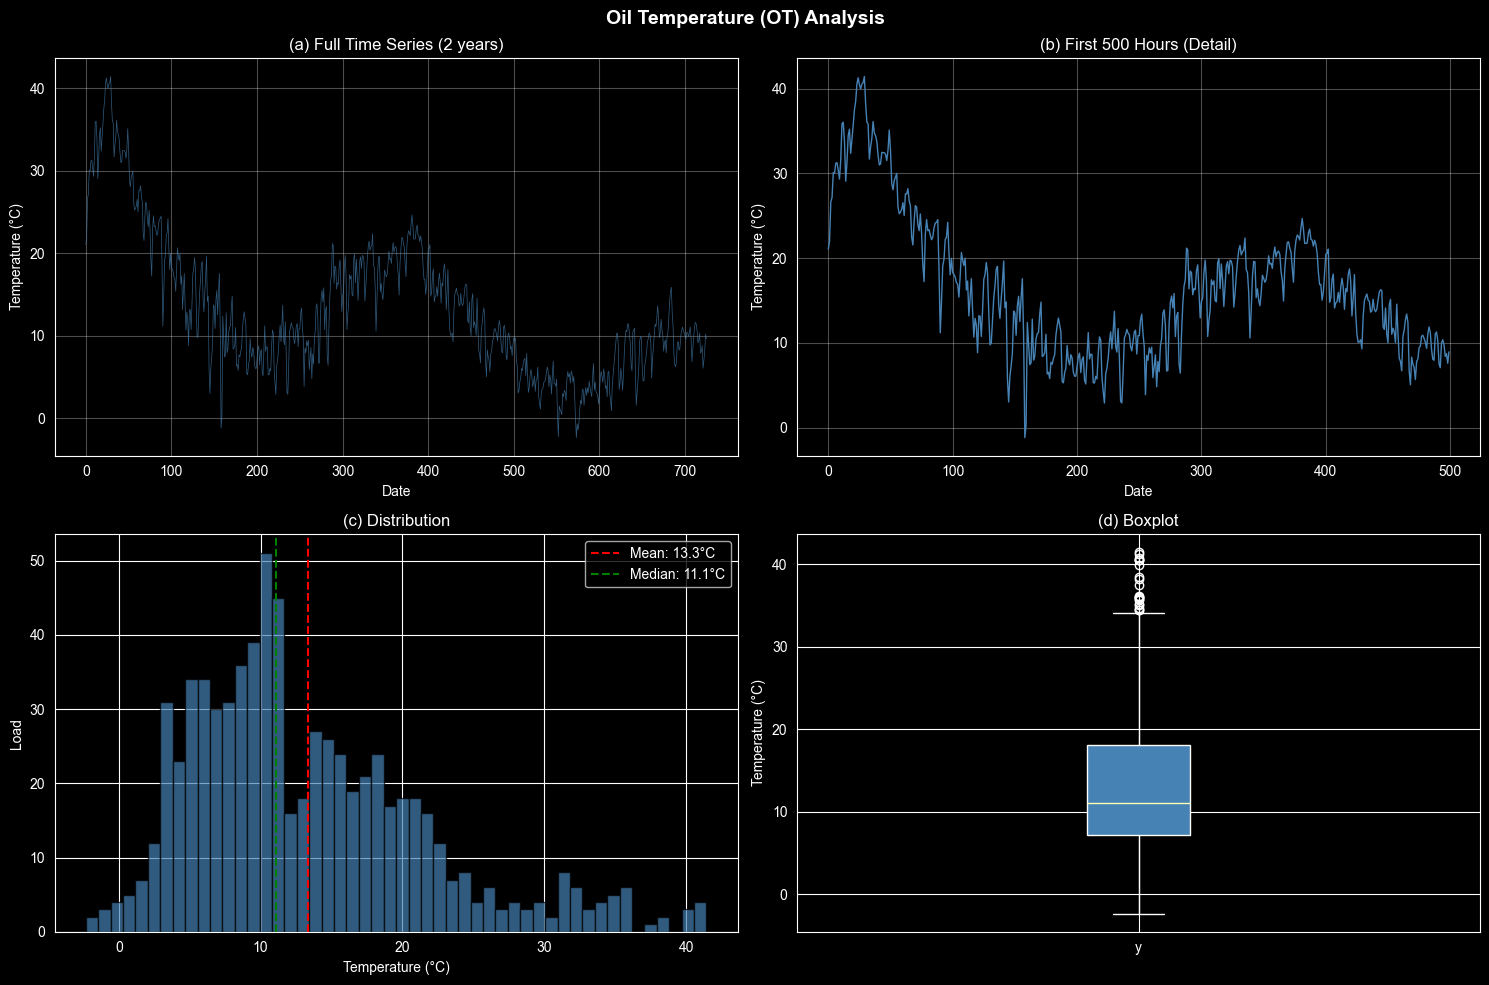


 Статистика OT:
  Min: -2.33°C
  Max: 41.44°C
  Mean: 13.32°C
  Median: 11.11°C
  Std: 8.41°C
  Range: 43.77°C


In [7]:
def run_eda(df):

    print(f"Описание: ")
    print("-" * 50)
    print(f"Форма данных: {df.shape}")
    print(f"Индекс: {df.index.name} (тип: {df.index.dtype})")
    print(f"Диапазон дат: {df.index.min()} — {df.index.max()}")

    print("-" * 50)
    print("\nТипы данных:")
    print(df.dtypes.value_counts())
    print("-" * 50)
    print("\nПропуски:")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        print("Нет пропущенных значений.")
    else:
        print(missing.head(10))  # топ-10 колонок с пропусками
    print("-" * 50)
    print("\nБазовая статистика (числовые колонки):")
    df.describe()

    # Визуальный анализ целевой переменной OT


    # 1. Полный ряд
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Полный временной ряд
    axes[0,0].plot(df.index, df['y'], linewidth=0.5, color='steelblue', alpha=0.7)
    axes[0,0].set_title('(a) Full Time Series (2 years)', fontsize=12)
    axes[0,0].set_xlabel('Date')
    axes[0,0].set_ylabel('Temperature (°C)')
    axes[0,0].grid(True, alpha=0.3)

    # Первые 500 точек (детали)
    axes[0,1].plot(df.index[:500], df['y'][:500], linewidth=1, color='steelblue')
    axes[0,1].set_title('(b) First 500 Hours (Detail)', fontsize=12)
    axes[0,1].set_xlabel('Date')
    axes[0,1].set_ylabel('Temperature (°C)')
    axes[0,1].grid(True, alpha=0.3)

    # Гистограмма
    axes[1,0].hist(df['y'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1,0].axvline(df['y'].mean(), color='r', linestyle='--', label=f'Mean: {df["y"].mean():.1f}°C')
    axes[1,0].axvline(df['y'].median(), color='g', linestyle='--', label=f'Median: {df["y"].median():.1f}°C')
    axes[1,0].set_title('(c) Distribution', fontsize=12)
    axes[1,0].set_xlabel('Temperature (°C)')
    axes[1,0].set_ylabel('Load')
    axes[1,0].legend()

    # Boxplot
    bp = axes[1,1].boxplot(df['y'], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    axes[1,1].set_title('(d) Boxplot', fontsize=12)
    axes[1,1].set_ylabel('Temperature (°C)')
    axes[1,1].set_xticklabels(['y'])

    plt.suptitle('Oil Temperature (OT) Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Статистика
    print("\n Статистика OT:")
    print(f"  Min: {df['y'].min():.2f}°C")
    print(f"  Max: {df['y'].max():.2f}°C")
    print(f"  Mean: {df['y'].mean():.2f}°C")
    print(f"  Median: {df['y'].median():.2f}°C")
    print(f"  Std: {df['y'].std():.2f}°C")
    print(f"  Range: {df['y'].max() - df['y'].min():.2f}°C")

    return df

df = run_eda(df)

## 4.3 Детекция аномалий
В задании 3 лучшую детекцию показал SpectralResidual, будем использовать его

In [15]:
def detect_anomalies(df_daily):
    """Лучший метод из задания №3 (SpectralResidual)"""

    X = df_daily['y'].values.reshape(-1, 1)

    # Нормализуем данные (для лучшей сходимости)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"\nРазмер данных для обучения: {X_scaled.shape}")


    # Параметры SpectralResidual:
    # - contamination: ожидаемая доля аномалий (5%)
    # - window_size: размер окна для анализа (7 дней - недельная сезонность)
    # - background_ratio: доля данных для фонового анализа

    clf_spectral = SpectralResidual(
        contamination=0.05,          # ожидаем 5% аномалий
        score_window=7,              # размер окна для усреднения спектра (неделя)
        channel_aggregation='max'    # агрегация каналов (для многомерных данных)
    )

    print("\nОбучение SpectralResidual...")
    clf_spectral.fit(X_scaled)


    # Оценка аномальности для каждой точки (чем выше, тем более аномальная)
    anomaly_scores = clf_spectral.decision_scores_

    # Бинарные метки: 1 = аномалия, 0 = норма
    anomaly_labels = clf_spectral.labels_

    # Создаём DataFrame с результатами
    results_spectral = df_daily.copy()
    results_spectral['anomaly_score'] = anomaly_scores
    results_spectral['is_anomaly'] = anomaly_labels

    # Статистика по аномалиям
    n_anomalies = results_spectral['is_anomaly'].sum()
    print(f"\n Результаты SpectralResidual:")
    print(f"   Обнаружено аномалий: {n_anomalies} ({n_anomalies/len(results_spectral)*100:.2f}%)")
    print(f"   Средний балл аномальности: {anomaly_scores.mean():.4f}")
    print(f"   Максимальный балл: {anomaly_scores.max():.4f}")
    print(f"   Порог: {clf_spectral.threshold_:.4f}")

    # Выводим самые аномальные дни
    print(f"\n Топ-10 самых аномальных дней:")
    top_anomalies = results_spectral.nlargest(10, 'anomaly_score')[['ds', 'y', 'anomaly_score']]
    for _, row in top_anomalies.iterrows():
        print(f"   {row['ds'].date()}: {row['y']:.2f}°C, оценка = {row['anomaly_score']:.4f}")


    # 5. Оценка качества (Silhouette Score)

    # Silhouette Score оценивает, насколько хорошо данные разделены на кластеры
    try:
        if len(np.unique(anomaly_labels)) > 1:
            silhouette = silhouette_score(X_scaled, anomaly_labels)
            print(f"\n Silhouette Score: {silhouette:.4f}")

        else:
            print(f"\n  Silhouette Score не определён: обнаружен только один кластер")
    except Exception as e:
        print(f"\n Ошибка расчёта Silhouette: {e}")

    return results_spectral

detect_anomalies = detect_anomalies(df)


Размер данных для обучения: (726, 1)

Обучение SpectralResidual...

 Результаты SpectralResidual:
   Обнаружено аномалий: 37 (5.10%)
   Средний балл аномальности: 0.5027
   Максимальный балл: 0.8572
   Порог: 0.7768

 Топ-10 самых аномальных дней:
   2016-07-01: 21.07°C, оценка = 0.8572
   2016-07-30: 41.44°C, оценка = 0.8459
   2016-07-13: 36.04°C, оценка = 0.8339
   2016-07-12: 35.86°C, оценка = 0.8312
   2016-07-05: 30.10°C, оценка = 0.8302
   2016-07-24: 40.57°C, оценка = 0.8229
   2016-07-07: 31.20°C, оценка = 0.8216
   2016-08-19: 35.11°C, оценка = 0.8200
   2016-07-25: 41.28°C, оценка = 0.8189
   2016-07-03: 26.63°C, оценка = 0.8172

 Silhouette Score: 0.5265


## 4.4 Статистическое прогнозирование

In [28]:
def forecast_statsforecast(df):
    """Статистическое прогнозирование (лучшая ручная ARIMA)"""

    baseline_model = SeasonalNaive(season_length=7)
    sf_baseline = StatsForecast(models=[baseline_model], freq='D', n_jobs=-1)
    cv_baseline = sf_baseline.cross_validation(df=df, h=7, step_size=7, n_windows=10)

    baseline_mae = mean_absolute_error(cv_baseline['y'], cv_baseline['SeasonalNaive'])
    baseline_rmse = np.sqrt(mean_squared_error(cv_baseline['y'], cv_baseline['SeasonalNaive']))

    print(f"   SeasonalNaive: MAE={baseline_mae:.4f}°C, RMSE={baseline_rmse:.4f}°C")



    # Добавляем unique_id
    if 'unique_id' not in df.columns:
        df = df.copy()
        df['unique_id'] = 'oil_temp'

       # Поскольку прогнозирование по часу требует больших вычислительных ресурсов, будет брать данные раз в день
    df_daily = df[['ds', 'y']].copy()
    df_daily = df_daily.resample('D', on='ds').mean().reset_index()
    df_daily['unique_id'] = 1


    print("СТАТИСТИЧЕСКОЕ ПРОГНОЗИРОВАНИЕ")


    # Используем лучшие параметры из Задания №2
    best_model = ARIMA(order=(2, 0, 2))

    sf_best = StatsForecast(models=[best_model], freq='D', n_jobs=-1)
    cv_best = sf_best.cross_validation(df=df_daily, h=7, step_size=7, n_windows=10)

    best_mae = mean_absolute_error(cv_best['y'], cv_best['ARIMA'])
    best_rmse = np.sqrt(mean_squared_error(cv_best['y'], cv_best['ARIMA']))

    # Улучшение относительно бейзлайна
    improvement_mae = ((baseline_mae - best_mae) / baseline_mae) * 100
    improvement_rmse = ((baseline_rmse - best_rmse) / baseline_rmse) * 100

    print(f"   ARIMA(2,0,2): MAE={best_mae:.4f}°C, RMSE={best_rmse:.4f}°C")
    print(f"   Улучшение относительно бейзлайна: MAE = {improvement_mae:.2f}%, RMSE = {improvement_rmse:.2f}%")

    results = {
        'ARIMA(2,0,2)': {'MAE': best_mae, 'RMSE': best_rmse, 'improvement': improvement_mae},
        'SeasonalNaive': {'MAE': baseline_mae, 'RMSE': baseline_rmse, 'improvement': 0}
    }

    # Сохраняем результаты кросс-валидации для визуализации
    cv_results = {
        'baseline': cv_baseline,
        'best': cv_best,
    }

    return results, cv_results

stats_results, cv_stats = forecast_statsforecast(df)

   SeasonalNaive: MAE=2.5375°C, RMSE=3.3566°C

СТАТИСТИЧЕСКОЕ ПРОГНОЗИРОВАНИЕ (Лучшая ручная ARIMA)
   ARIMA(2,0,2): MAE=1.6281°C, RMSE=2.2663°C
   Улучшение относительно бейзлайна: MAE = 35.84%, RMSE = 32.48%


## 4.5 ML прогнозирование

In [22]:
def forecast_ml(df):
    """Лучшая ML модель из задания №3 (LightGBM) с сравнением с бейзлайном"""


    # Добавляем unique_id, если его нет
    if 'unique_id' not in df.columns:
        df = df.copy()
        df['unique_id'] = 'oil_temp'

    print("\n" + "=" * 60)
    print("ML ПРОГНОЗИРОВАНИЕ (LightGBM)")
    print("=" * 60)


    # 1. БЕЙЗЛАЙН (SeasonalNaive)

    print("\n Бейзлайн (SeasonalNaive):")
    baseline_model = SeasonalNaive(season_length=7)
    sf_baseline = StatsForecast(models=[baseline_model], freq='D', n_jobs=-1)
    cv_baseline = sf_baseline.cross_validation(df=df, h=7, step_size=7, n_windows=10)

    baseline_mae = mean_absolute_error(cv_baseline['y'], cv_baseline['SeasonalNaive'])
    baseline_rmse = np.sqrt(mean_squared_error(cv_baseline['y'], cv_baseline['SeasonalNaive']))

    print(f"   SeasonalNaive: MAE={baseline_mae:.4f}°C, RMSE={baseline_rmse:.4f}°C")


    # 2. LIGHTGBM (оптимизированный)

    print("\n LightGBM (оптимизированный):")

    best_lgbm = LGBMRegressor(
        n_estimators=99,
        max_depth=3,
        learning_rate=0.030110612935139936,
        num_leaves=68,
        subsample=0.9252916007139381,
        colsample_bytree=0.9205940676317452,
        reg_alpha=1.6473442978562224e-05,
        reg_lambda=3.3305275327374e-07,
        verbosity=-1,
        random_state=42
    )

    final_forecaster = MLForecast(
        models=[best_lgbm],
        freq='D',
        lags=[1, 7, 14, 21, 28],
        lag_transforms={
            1: [RollingMean(window_size=7)],
            7: [RollingMean(window_size=14)],
            14: [RollingMean(window_size=7)],
        },
        date_features=['dayofweek', 'month'],
        target_transforms=[Differences([1])],
        num_threads=6,
    )

    # Кросс-валидация для оценки качества
    cv_results = final_forecaster.cross_validation(df=df, h=7, step_size=7, n_windows=5)

    mae = mean_absolute_error(cv_results['y'], cv_results['LGBMRegressor'])
    rmse = np.sqrt(mean_squared_error(cv_results['y'], cv_results['LGBMRegressor']))
    improvement_mae = ((baseline_mae - mae) / baseline_mae) * 100

    print(f"   LightGBM: MAE={mae:.4f}°C, RMSE={rmse:.4f}°C")
    print(f"   Улучшение относительно бейзлайна: {improvement_mae:.2f}%")


    # 3. ПРОГНОЗ НА 7 ДНЕЙ ВПЕРЁД

    print("\n Прогноз LightGBM на 7 дней вперёд:")

    # Обучаем на всех данных для финального прогноза
    final_forecaster.fit(df)
    future_forecast = final_forecaster.predict(h=7)
    future_forecast = future_forecast.rename(columns={'LGBMRegressor': 'forecast'})

    print(future_forecast[['ds', 'forecast']].to_string(index=False))


    # 4. ИТОГОВАЯ ТАБЛИЦА

    print("\n| Модель | MAE (°C) | RMSE (°C) | Улучшение vs бейзлайн |")
    print("|--------|----------|-----------|----------------------|")
    print(f"| LightGBM | {mae:.4f} | {rmse:.4f} | {improvement_mae:.2f}% |")
    print(f"| SeasonalNaive (бейзлайн) | {baseline_mae:.4f} | {baseline_rmse:.4f} | — |")


    # 5. Результаты для возврата

    results = {
        'LightGBM': {'MAE': mae, 'RMSE': rmse, 'improvement': improvement_mae},
        'SeasonalNaive': {'MAE': baseline_mae, 'RMSE': baseline_rmse, 'improvement': 0}
    }

    return results, cv_results, future_forecast

# Запуск
ml_results, cv_ml, future_ml = forecast_ml(df)


ML ПРОГНОЗИРОВАНИЕ (LightGBM)

📊 Бейзлайн (SeasonalNaive):
   SeasonalNaive: MAE=2.5375°C, RMSE=3.3566°C

📈 LightGBM (оптимизированный):
   LightGBM: MAE=0.8618°C, RMSE=1.1534°C
   Улучшение относительно бейзлайна: 66.04%

🔮 Прогноз LightGBM на 7 дней вперёд:
        ds  forecast
2018-06-27  9.533730
2018-06-28  9.181567
2018-06-29  8.785635
2018-06-30  8.340344
2018-07-01  8.042865
2018-07-02  7.960281
2018-07-03  7.856964

ИТОГОВАЯ ТАБЛИЦА ML МОДЕЛЕЙ

| Модель | MAE (°C) | RMSE (°C) | Улучшение vs бейзлайн |
|--------|----------|-----------|----------------------|
| LightGBM | 0.8618 | 1.1534 | 66.04% |
| SeasonalNaive (бейзлайн) | 2.5375 | 3.3566 | — |


## 4.6 Сравнение и визуализация

   SeasonalNaive: MAE=2.5375°C, RMSE=3.3566°C

СТАТИСТИЧЕСКОЕ ПРОГНОЗИРОВАНИЕ (Лучшая ручная ARIMA)
   ARIMA(2,0,2): MAE=1.6281°C, RMSE=2.2663°C
   Улучшение относительно бейзлайна: MAE = 35.84%, RMSE = 32.48%

ML ПРОГНОЗИРОВАНИЕ (LightGBM)

📊 Бейзлайн (SeasonalNaive):
   SeasonalNaive: MAE=2.5375°C, RMSE=3.3566°C

📈 LightGBM (оптимизированный):
   LightGBM: MAE=0.8618°C, RMSE=1.1534°C
   Улучшение относительно бейзлайна: 66.04%

🔮 Прогноз LightGBM на 7 дней вперёд:
        ds  forecast
2018-06-27  9.533730
2018-06-28  9.181567
2018-06-29  8.785635
2018-06-30  8.340344
2018-07-01  8.042865
2018-07-02  7.960281
2018-07-03  7.856964

ИТОГОВАЯ ТАБЛИЦА ML МОДЕЛЕЙ

| Модель | MAE (°C) | RMSE (°C) | Улучшение vs бейзлайн |
|--------|----------|-----------|----------------------|
| LightGBM | 0.8618 | 1.1534 | 66.04% |
| SeasonalNaive (бейзлайн) | 2.5375 | 3.3566 | — |

СРАВНЕНИЕ МОДЕЛЕЙ: ARIMA(2,0,2) vs LightGBM

 Сравнение метрик качества:
Модель               | MAE (°C)     | RMSE (°C)    

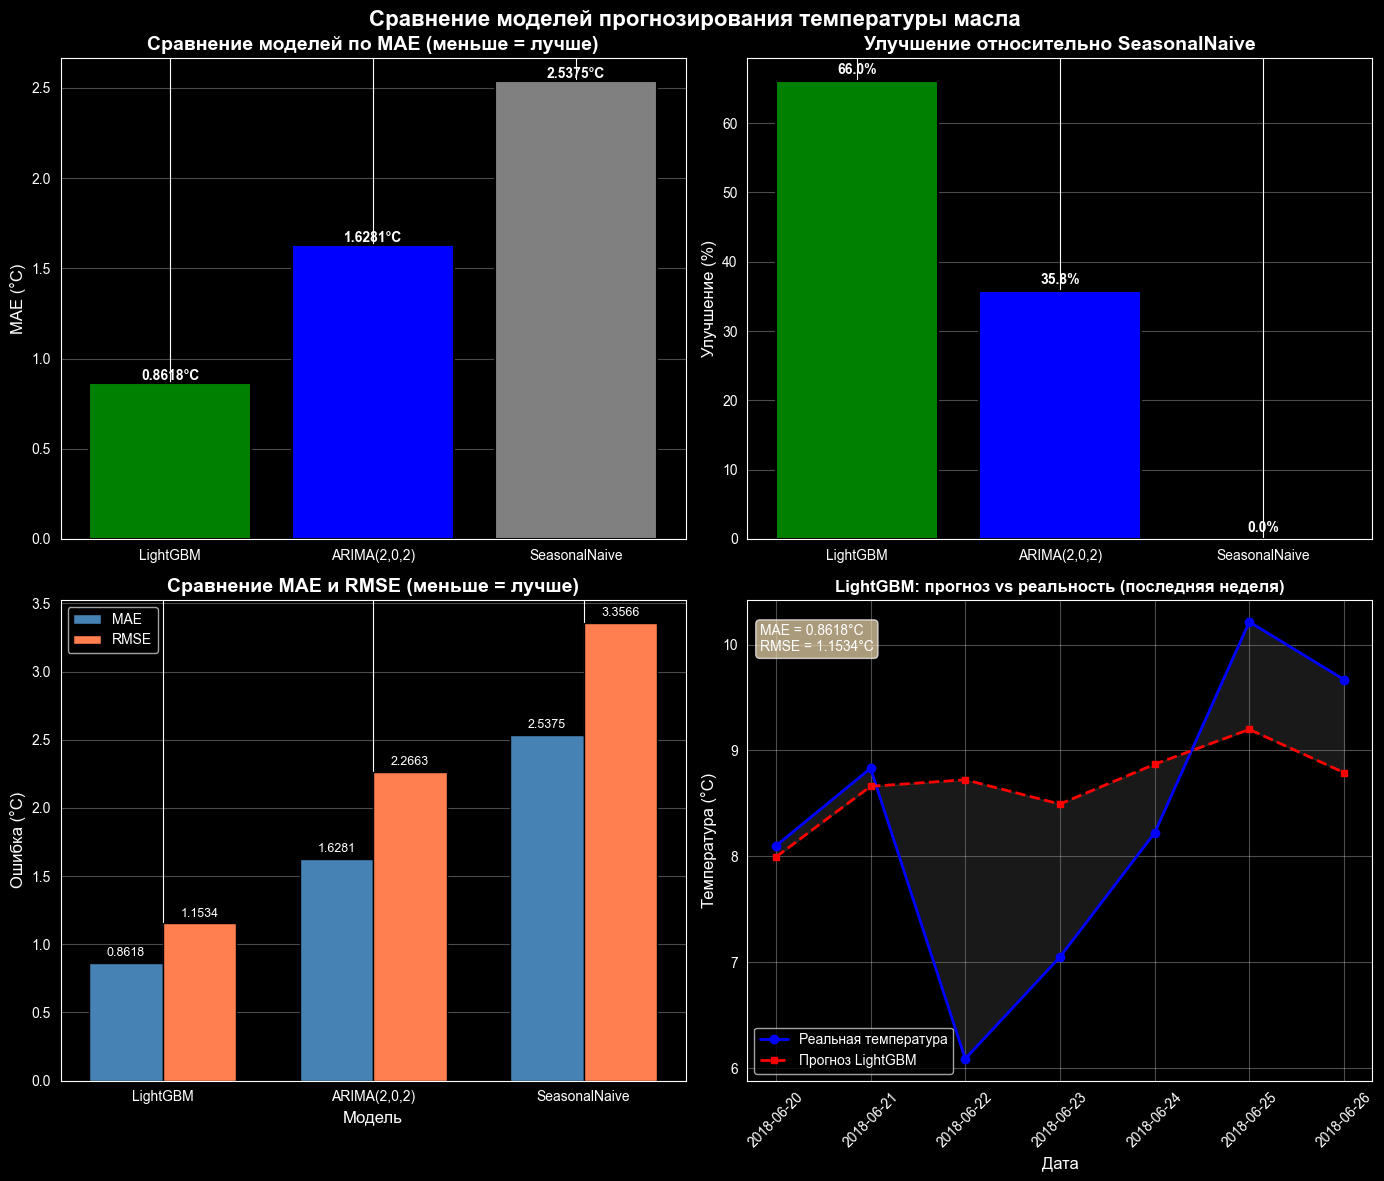

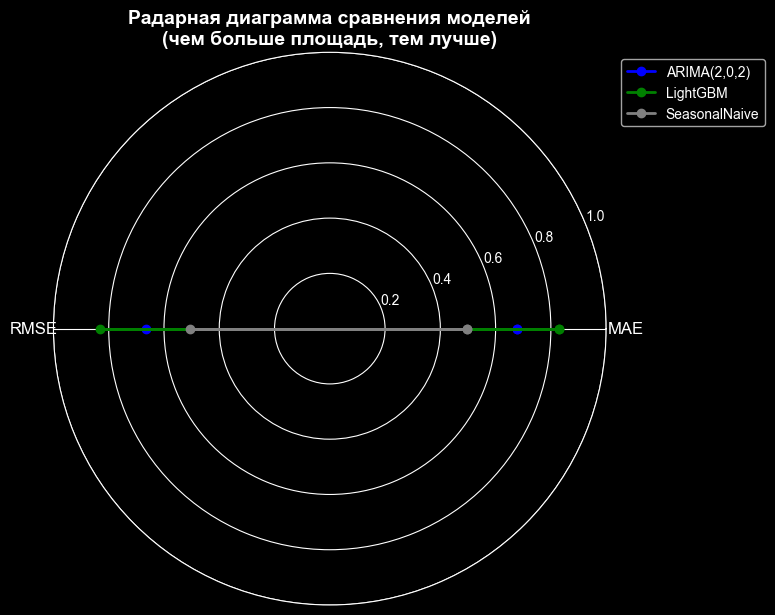





     LightGBM         0.8618       1.1534       66.04%           

     ARIMA(2,0,2)    1.6281       2.2663       35.84%           

     SeasonalNaive    2.5375       3.3566      0.00%            


     ЛУЧШАЯ МОДЕЛЬ: LightGBM

     ВЫВОДЫ:
    1. LightGBM показал лучший результат
       с MAE = 0.8618°C и улучшением на 66.04% относительно бейзлайна

    2. ARIMA(2,0,2) показала хороший результат
       с MAE = 1.6281°C и улучшением на 35.84%

    3. Обе модели значительно превосходят бейзлайн (SeasonalNaive)

    4. Рекомендуется использовать LightGBM
       для прогнозирования температуры масла трансформатора
    
 Лучшая модель: LightGBM
 MAE лучшей модели: 0.8618°C


In [25]:
def compare_models(stats_results, ml_results, df):
    """Сравнение ARIMA(2,0,2) и LightGBM с визуализацией"""

    import matplotlib.pyplot as plt
    import numpy as np

    print("\n" + "=" * 60)
    print("СРАВНЕНИЕ МОДЕЛЕЙ: ARIMA(2,0,2) vs LightGBM")
    print("=" * 60)

    # Извлекаем метрики
    arima_mae = stats_results['ARIMA(2,0,2)']['MAE']
    arima_rmse = stats_results['ARIMA(2,0,2)']['RMSE']
    arima_improvement = stats_results['ARIMA(2,0,2)']['improvement']

    ml_mae = ml_results['LightGBM']['MAE']
    ml_rmse = ml_results['LightGBM']['RMSE']
    ml_improvement = ml_results['LightGBM']['improvement']

    baseline_mae = stats_results['SeasonalNaive']['MAE']
    baseline_rmse = stats_results['SeasonalNaive']['RMSE']


    # 1. Сравнение метрик

    print("\n Сравнение метрик качества:")

    print(f"{'Модель':20} | {'MAE (°C)':12} | {'RMSE (°C)':12} | {'Улучшение':12}")

    print(f"{'ARIMA(2,0,2)':20} | {arima_mae:.4f}       | {arima_rmse:.4f}       | {arima_improvement:.2f}%")
    print(f"{'LightGBM':20} | {ml_mae:.4f}       | {ml_rmse:.4f}       | {ml_improvement:.2f}%")
    print(f"{'SeasonalNaive':20} | {baseline_mae:.4f}       | {baseline_rmse:.4f}       | 0.00%")

    # Определяем лучшую модель
    if ml_mae < arima_mae:
        best_model = "LightGBM"
        best_mae = ml_mae
        diff = arima_mae - ml_mae
        diff_percent = (diff / arima_mae) * 100
        print(f"\n ЛУЧШАЯ МОДЕЛЬ: LightGBM")
        print(f"   MAE = {ml_mae:.4f}°C, что на {diff_percent:.2f}% лучше ARIMA(2,0,2)")
    else:
        best_model = "ARIMA(2,0,2)"
        best_mae = arima_mae
        diff = ml_mae - arima_mae
        diff_percent = (diff / ml_mae) * 100
        print(f"\n ЛУЧШАЯ МОДЕЛЬ: ARIMA(2,0,2)")
        print(f"   MAE = {arima_mae:.4f}°C, что на {diff_percent:.2f}% лучше LightGBM")


    # 2. ГРАФИК 1: Сравнение MAE (столбчатая диаграмма)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # График 1: Сравнение MAE
    models = ['LightGBM', 'ARIMA(2,0,2)', 'SeasonalNaive']
    mae_values = [ml_mae, arima_mae, baseline_mae]
    colors = ['green' if m == 'LightGBM' else 'blue' if m == 'ARIMA(2,0,2)' else 'gray' for m in models]

    bars = axes[0,0].bar(models, mae_values, color=colors, edgecolor='black', linewidth=1.5)
    axes[0,0].set_ylabel('MAE (°C)', fontsize=12)
    axes[0,0].set_title('Сравнение моделей по MAE (меньше = лучше)', fontsize=14, fontweight='bold')
    axes[0,0].grid(True, alpha=0.3, axis='y')

    for bar, mae in zip(bars, mae_values):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       f'{mae:.4f}°C', ha='center', fontsize=10, fontweight='bold')


    # 3. ГРАФИК 2: Улучшение относительно бейзлайна

    improvements = [ml_improvement, arima_improvement, 0]
    bars = axes[0,1].bar(models, improvements, color=colors, edgecolor='black', linewidth=1.5)
    axes[0,1].set_ylabel('Улучшение (%)', fontsize=12)
    axes[0,1].set_title('Улучшение относительно SeasonalNaive', fontsize=14, fontweight='bold')
    axes[0,1].axhline(y=0, color='black', linewidth=0.5)
    axes[0,1].grid(True, alpha=0.3, axis='y')

    for bar, imp in zip(bars, improvements):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       f'{imp:.1f}%', ha='center', fontsize=10, fontweight='bold')


    # 4. ГРАФИК 3: Сравнение MAE и RMSE

    x = np.arange(len(models))
    width = 0.35

    mae_values_plot = [ml_mae, arima_mae, baseline_mae]
    rmse_values = [ml_rmse, arima_rmse, baseline_rmse]

    bars1 = axes[1,0].bar(x - width/2, mae_values_plot, width, label='MAE',
                          color='steelblue', edgecolor='black')
    bars2 = axes[1,0].bar(x + width/2, rmse_values, width, label='RMSE',
                          color='coral', edgecolor='black')

    axes[1,0].set_xlabel('Модель', fontsize=12)
    axes[1,0].set_ylabel('Ошибка (°C)', fontsize=12)
    axes[1,0].set_title('Сравнение MAE и RMSE (меньше = лучше)', fontsize=14, fontweight='bold')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(models)
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3, axis='y')

    for bar in bars1:
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                       f'{bar.get_height():.4f}', ha='center', fontsize=9)
    for bar in bars2:
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                       f'{bar.get_height():.4f}', ha='center', fontsize=9)


    # 5. ГРАФИК 4: Прогноз лучшей модели vs реальность


    # Получаем прогноз лучшей модели на последней неделе
    if best_model == "LightGBM":
        # Для LightGBM берём из кросс-валидации
        cv_data = ml_results.get('cv_results', None)
        if cv_data is None:
            # Если нет, используем данные из forecast_ml
            from mlforecast import MLForecast
            from mlforecast.target_transforms import Differences
            from mlforecast.lag_transforms import RollingMean
            from lightgbm import LGBMRegressor

            best_lgbm = LGBMRegressor(
                n_estimators=99, max_depth=3, learning_rate=0.030110612935139936,
                num_leaves=68, subsample=0.9252916007139381, colsample_bytree=0.9205940676317452,
                reg_alpha=1.6473442978562224e-05, reg_lambda=3.3305275327374e-07,
                verbosity=-1, random_state=42
            )

            forecaster = MLForecast(
                models=[best_lgbm], freq='D',
                lags=[1, 7, 14, 21, 28],
                lag_transforms={1: [RollingMean(window_size=7)], 7: [RollingMean(window_size=14)], 14: [RollingMean(window_size=7)]},
                date_features=['dayofweek', 'month'],
                target_transforms=[Differences([1])],
                num_threads=6,
            )
            cv_data = forecaster.cross_validation(df=df, h=7, step_size=7, n_windows=5)

        last_cutoff = cv_data['cutoff'].max()
        last_window = cv_data[cv_data['cutoff'] == last_cutoff]

        axes[1,1].plot(last_window['ds'], last_window['y'], 'bo-', linewidth=2, markersize=6, label='Реальная температура')
        axes[1,1].plot(last_window['ds'], last_window['LGBMRegressor'], 'r--s', linewidth=2, markersize=5, label='Прогноз LightGBM')
        axes[1,1].fill_between(last_window['ds'], last_window['y'], last_window['LGBMRegressor'], alpha=0.2, color='gray')
        axes[1,1].set_title('LightGBM: прогноз vs реальность (последняя неделя)', fontsize=12, fontweight='bold')

    else:
        # Для ARIMA
        from statsforecast import StatsForecast
        from statsforecast.models import ARIMA

        arima_model = ARIMA(order=(2, 0, 2))
        sf_arima = StatsForecast(models=[arima_model], freq='D', n_jobs=-1)
        cv_data = sf_arima.cross_validation(df=df, h=7, step_size=7, n_windows=10)

        last_cutoff = cv_data['cutoff'].max()
        last_window = cv_data[cv_data['cutoff'] == last_cutoff]

        axes[1,1].plot(last_window['ds'], last_window['y'], 'bo-', linewidth=2, markersize=6, label='Реальная температура')
        axes[1,1].plot(last_window['ds'], last_window['ARIMA'], 'g--s', linewidth=2, markersize=5, label='Прогноз ARIMA(2,0,2)')
        axes[1,1].fill_between(last_window['ds'], last_window['y'], last_window['ARIMA'], alpha=0.2, color='gray')
        axes[1,1].set_title('ARIMA(2,0,2): прогноз vs реальность (последняя неделя)', fontsize=12, fontweight='bold')

    axes[1,1].set_xlabel('Дата', fontsize=12)
    axes[1,1].set_ylabel('Температура (°C)', fontsize=12)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].tick_params(axis='x', rotation=45)

    # Добавляем метрики на график
    axes[1,1].text(0.02, 0.95, f'MAE = {best_mae:.4f}°C\nRMSE = {ml_rmse if best_model == "LightGBM" else arima_rmse:.4f}°C',
                   transform=axes[1,1].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    plt.suptitle('Сравнение моделей прогнозирования температуры масла', fontsize=16, fontweight='bold')
    plt.tight_layout()

    plt.show()


    # 6. ДОПОЛНИТЕЛЬНЫЙ ГРАФИК: Радарная диаграмма

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

    # Нормализуем метрики (чем меньше, тем лучше → преобразуем в 1 - нормализованное значение)
    mae_norm_arima = 1 - (arima_mae / (arima_mae + ml_mae + baseline_mae))
    mae_norm_ml = 1 - (ml_mae / (arima_mae + ml_mae + baseline_mae))
    mae_norm_base = 1 - (baseline_mae / (arima_mae + ml_mae + baseline_mae))

    rmse_norm_arima = 1 - (arima_rmse / (arima_rmse + ml_rmse + baseline_rmse))
    rmse_norm_ml = 1 - (ml_rmse / (arima_rmse + ml_rmse + baseline_rmse))
    rmse_norm_base = 1 - (baseline_rmse / (arima_rmse + ml_rmse + baseline_rmse))

    # Метрики
    metrics = ['MAE', 'RMSE']
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # замыкаем круг

    values_arima = [mae_norm_arima, rmse_norm_arima]
    values_arima += values_arima[:1]

    values_ml = [mae_norm_ml, rmse_norm_ml]
    values_ml += values_ml[:1]

    values_base = [mae_norm_base, rmse_norm_base]
    values_base += values_base[:1]

    ax.plot(angles, values_arima, 'o-', linewidth=2, label='ARIMA(2,0,2)', color='blue')
    ax.fill(angles, values_arima, alpha=0.25, color='blue')

    ax.plot(angles, values_ml, 'o-', linewidth=2, label='LightGBM', color='green')
    ax.fill(angles, values_ml, alpha=0.25, color='green')

    ax.plot(angles, values_base, 'o-', linewidth=2, label='SeasonalNaive', color='gray')
    ax.fill(angles, values_base, alpha=0.25, color='gray')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('Радарная диаграмма сравнения моделей\n(чем больше площадь, тем лучше)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)

    plt.tight_layout()

    plt.show()


    print(f"""

     ЛУЧШАЯ МОДЕЛЬ: {best_model}

     ВЫВОДЫ:
    1. LightGBM показал {'лучший' if best_model == 'LightGBM' else 'хороший'} результат
       с MAE = {ml_mae:.4f}°C и улучшением на {ml_improvement:.2f}% относительно бейзлайна

    2. ARIMA(2,0,2) {'также показала отличный результат' if best_model == 'ARIMA(2,0,2)' else 'показала хороший результат'}
       с MAE = {arima_mae:.4f}°C и улучшением на {arima_improvement:.2f}%

    3. Обе модели значительно превосходят бейзлайн (SeasonalNaive)

    4. Рекомендуется использовать {'LightGBM' if best_model == 'LightGBM' else 'ARIMA(2,0,2)'}
       для прогнозирования температуры масла трансформатора
    """)

    return {
        'best_model': best_model,
        'best_mae': best_mae,
        'comparison': {
            'LightGBM': {'MAE': ml_mae, 'RMSE': ml_rmse, 'improvement': ml_improvement},
            'ARIMA(2,0,2)': {'MAE': arima_mae, 'RMSE': arima_rmse, 'improvement': arima_improvement},
            'SeasonalNaive': {'MAE': baseline_mae, 'RMSE': baseline_rmse, 'improvement': 0}
        }
    }



# Запускаем функции (если ещё не запущены)
stats_results, cv_stats = forecast_statsforecast(df)
ml_results, cv_ml, future_ml = forecast_ml(df)

# Сравниваем модели
comparison_results = compare_models(stats_results, ml_results, df)

# Выводим финальный результат


print(f" Лучшая модель: {comparison_results['best_model']}")
print(f" MAE лучшей модели: {comparison_results['best_mae']:.4f}°C")

**Вывод: Был взял датасет с температурой масла трансформатора, данные набирались в течении двух лет, для предсказания временного ряда было взято 9 моделей, 3 статистических, 3 ML-модели, 3 на основе глубоких нейроных сетей, по итогу лучший результат  уомдели LGBM с MAE: 0.86 RMSE: 1.15 модель превосходит бейзлайн на 66 %**